In [1]:
import numpy as np
from scipy.sparse import spdiags, eye, kron
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

def u_func(x,y):
    return np.sin(4*np.pi*(x+y)) + np.cos(4*np.pi*x*y)

def f_func(x,y):
    term1 = -32*np.pi**2*np.sin(4*np.pi*(x+y))
    term2 = -16*np.pi**2*(x**2 + y**2)*np.cos(4*np.pi*x*y)
    return term1 + term2


def poisson5(m):
    e = np.ones(m)
    S = spdiags([e, -2*e, e], [-1, 0, 1], m, m)
    I = eye(m, format='csr')
    A = kron(I, S) + kron(S, I)
    A = (m + 1)**2 * A
    return A.tocsr()

def form_rhs(m, f_func, u_func):

    h = 1.0/(m+1)
    b = np.zeros(m*m)

    for j in range(1, m+1):
        for i in range(1, m+1):

            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 1:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 1:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m:
                b[k] -= u_func(x,1)/h**2

    return b


In [2]:
def sanity(m, f_func, u_func):
    '''
        # INPUTS
            m: number of INTERIOR points in the discretized domain
            f_func: RHS as a analytical function of (x,y) of the BVP
            u_func: DC boundary as analytical function of (x,y)

        # OUTPUT
            b: discretized RHS of the interior points in the discretized domain
    '''

    h = 1.0/(m+1)
    b = np.zeros(m**2)

    for j in range(m):
        for i in range(m):

            k = j*m + i
            x = (i+1)*h
            y = (j+1)*h

            b[k] = f_func(x,y)

            # left boundary
            if i == 0:
                b[k] -= u_func(0,y)/h**2

            # right boundary
            if i == m-1:
                b[k] -= u_func(1,y)/h**2

            # bottom boundary
            if j == 0:
                b[k] -= u_func(x,0)/h**2

            # top boundary
            if j == m-1:
                b[k] -= u_func(x,1)/h**2

    return b

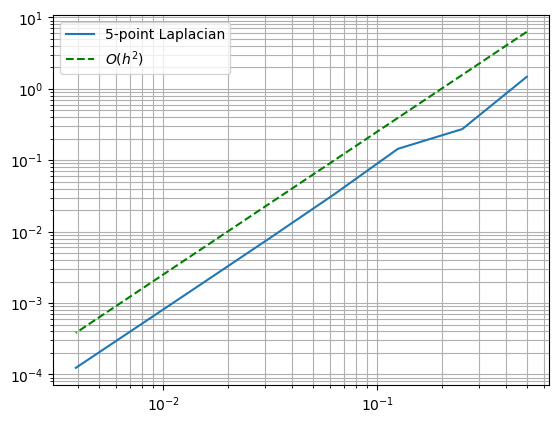

In [ ]:
hs = []
errs = []

for i in range(1,9):
    h = (1/2)**i
    m = int(1.0/h-1)
    
    A = poisson5(m).tocsr()          
    F = form_rhs(m,f_func,u_func)
    
    v = spsolve(A, F)
    
    x_interior = np.linspace(h, 1-h, m)
    y_interior = np.linspace(h, 1-h, m)
    X, Y = np.meshgrid(x_interior, y_interior, indexing='ij')
    U_exact = u_func(X, Y)
    
    err = v - U_exact.flatten()
    l2err = np.sqrt(h**2 * np.sum(err**2))
    
    hs.append(h)
    errs.append(l2err)

plt.loglog(hs, errs, '-',label=r"5-point Laplacian")
#plt.xlabel("h")
#plt.ylabel("L2 error")
plt.loglog(hs,25*np.array(hs)**2, 'g--', label=r"$O(h^2)$")
#plt.loglog(hs,errs,color="orange", label=r"$(\alpha, \beta) = (2,2)$")
plt.grid(True, which='both')
plt.legend()
plt.show()

In [4]:
np.polyfit(np.log(hs[3:]),np.log(errs[3:]),1)

array([2.01067212, 2.14487385])

In [5]:
def poisson9(m):
    e = np.ones(m)
    S = spdiags([-e, -10*e, -e], [-1, 0, 1], m, m)
    I = spdiags([-0.5*e, e, -0.5*e], [-1, 0, 1], m, m)
    A = (1/6) * (m + 1)**2 * (kron(I, S) + kron(S, I))
    return A.tocsr()

def laplace_f(x,y):
    term1 = 1024*np.pi**4*np.sin(4*np.pi*(x+y))
    term2a = -64*np.pi**2*np.cos(4*np.pi*x*y)
    term2b = 512*np.pi**3*x*y*np.sin(4*np.pi*x*y)
    term2c = 256*np.pi**4*(x**2+y**2)**2*np.cos(4*np.pi*x*y)
    return term1 + term2a + term2b + term2c

def form_rhs9(m, f_func, u_func):
    h = 1.0/(m+1)
    b = np.zeros(m*m)

    w_axial  = 4 / (6 * h**2)
    w_corner = 1 / (6 * h**2)

    axial = [(1,0),(-1,0),(0,1),(0,-1)]
    diag  = [(1,1),(1,-1),(-1,1),(-1,-1)]

    for j in range(1, m+1):
        for i in range(1, m+1):
            k = (j-1)*m + (i-1)
            x = i*h
            y = j*h
            b[k] = f_func(x,y) +h**2/12 * laplace_f(x,y)


            for di,dj in axial:
                ni, nj = i+di, j+dj
                if ni < 1 or ni > m or nj < 1 or nj > m:
                    b[k] -= w_axial * u_func(ni*h, nj*h)

            for di,dj in diag:
                ni, nj = i+di, j+dj
                if ni < 1 or ni > m or nj < 1 or nj > m:
                    b[k] -= w_corner * u_func(ni*h, nj*h)

    return b

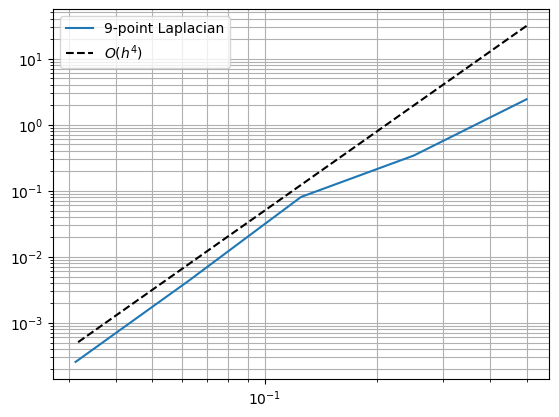

In [6]:
hs = []
l2errs = []
#linferrs = []

for i in range(1,6):
    h = (1/2)**i
    m = int(1.0/h-1)
    
    A = poisson9(m)    
    F = form_rhs9(m,f_func,u_func)
    
    v = spsolve(A, F)
    
    x_interior = np.linspace(h, 1-h, m)
    y_interior = np.linspace(h, 1-h, m)
    X, Y = np.meshgrid(x_interior, y_interior, indexing='ij')
    U_exact = u_func(X, Y)
    
    err = v - U_exact.flatten()
    l2err = np.sqrt(h**2*np.sum(err**2))
    #linferr = np.max(np.abs(err))
    
    hs.append(h)
    l2errs.append(l2err)
    #linferrs.append(linferr)

plt.loglog(hs, l2errs, '-',label=r"9-point Laplacian")
#plt.xlabel("h")
#plt.ylabel("L2 error")
plt.loglog(hs,500*np.array(hs)**4, 'k--', label=r"$O(h^4)$")
#plt.loglog(hs,errs,color="orange", label=r"$(\alpha, \beta) = (2,2)$")
plt.grid(True, which='both')
plt.legend()
plt.show()

In [7]:
np.polyfit(np.log(hs[3:]),np.log(l2errs[3:]),1)

array([4.06675229, 5.82060784])